In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
DATASET_PATH = "/content/drive/MyDrive/MV/dataset"


In [3]:
!ls $DATASET_PATH


fist  palm


In [4]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models


In [5]:
CLASSES = {
    "palm": 0,
    "fist": 1
}

IMG_SIZE = 64

X = []
y = []

print("Loading dataset...")

for class_name, label in CLASSES.items():
    folder = os.path.join(DATASET_PATH, class_name)
    print(f"Loading {class_name}: {folder}")

    for fname in os.listdir(folder):
        if not fname.lower().endswith(".png"):
            continue

        fpath = os.path.join(folder, fname)
        img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)

        if img is None:
            print("Skipping invalid image:", fpath)
            continue

        # resize if needed
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # normalize
        img = img.astype("float32") / 255.0

        X.append(img)
        y.append(label)

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 1)
y = np.array(y)

print("Loaded images:", X.shape)
print("Labels:", y.shape)


Loading dataset...
Loading palm: /content/drive/MyDrive/MV/dataset/palm
Loading fist: /content/drive/MyDrive/MV/dataset/fist
Loaded images: (809, 64, 64, 1)
Labels: (809,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (647, 64, 64, 1)
Test: (162, 64, 64, 1)


In [7]:
model = models.Sequential([
    layers.Conv2D(16, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 1)),
    layers.MaxPool2D(2,2),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPool2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPool2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 171,011 (668.01 KB)

 Trainable params: 171,011 (668.01 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)


Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.5528 - loss: 0.8207 - val_accuracy: 0.7231 - val_loss: 0.6051
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.7328 - loss: 0.5557 - val_accuracy: 0.7154 - val_loss: 0.4067
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.8703 - loss: 0.2914 - val_accuracy: 0.9769 - val_loss: 0.1221
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.9253 - loss: 0.1932 - val_accuracy: 0.9769 - val_loss: 0.0774
Epoch 5/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step - accuracy: 0.9842 - loss: 0.0659 - val_accuracy: 1.0000 - val_loss: 0.0235
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.9864 - loss: 0.0469 - val_accuracy: 1.0000 - val_loss: 0.0081
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 1.0000 - loss: 0.0103 - val_accuracy: 1.0000 - val_loss: 0.0039
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 1.0000 - loss: 0.0031 - val_accuracy: 1.0000 

In [9]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 1.9328e-04
Test Accuracy: 1.0


In [10]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("gesture_fp32.tflite", "wb") as f:
    f.write(tflite_model)


Saved artifact at '/tmp/tmp_aw41mvn'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  131945322888080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322889040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322888848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322886736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322888464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322887120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322886544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322887888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945320612496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945320613072: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [11]:
def rep_ds():
    for i in range(100):
        idx = np.random.randint(0, X_train.shape[0])
        yield [X_train[idx:idx+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = rep_ds
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.uint8
converter.inference_output_type = tf.uint8

tflite_int8 = converter.convert()

with open("gesture_int8.tflite", "wb") as f:
    f.write(tflite_int8)


Saved artifact at '/tmp/tmptbc0d6bp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  131945322888080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322889040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322888848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322886736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322888464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322887120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322886544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945322887888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945320612496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  131945320613072: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


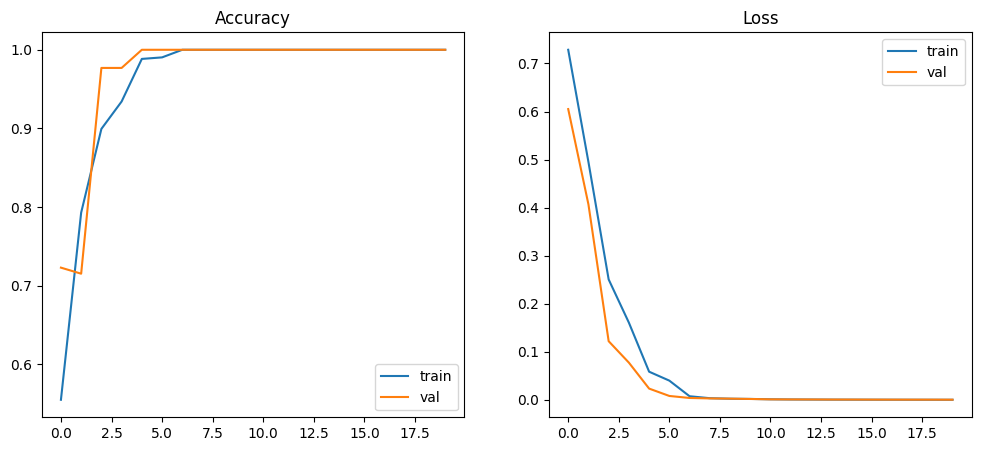

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['train','val'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['train','val'])

plt.show()


In [13]:
from google.colab import files
files.download("gesture_int8.tflite")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>